# Alanyze data using behavioral model
There are 3 models with different parameter combinations:

1. <b>The Bayesian model (Schwöbel et al. 2021):</b> \
   <b>a.</b> With 3 parameters: a policy forgetting rate $\lambda_{\pi}$, a reward forgetting rate $\lambda_{r}$, and a decision temparature $\beta$. \
   <b>b.</b> With 4 parameters: a policy forgetting rate $\lambda_{\pi}$, a reward forgetting rate $\lambda_{r}$, a decision temparature $\beta$, and a habitual tendency $h$.
2. <b>A newer MF/MB version that is better for fitting (Otto et al. 2013):</b> \
<b>Note:</b> This is not quite the original version, as the Q-values in the original work did not converge to the true expected values. Instead, I implemented a "bug-fixed" version.\
   <b>a.</b> With 4 parameters: a MF weight parameter $\beta_{MF}$, a MB weight parameter $\beta_{MB}$, a learning rate $\alpha$, and a dicount factor $\lambda$. \
   <b>b.</b> With 5 parameters: a MF weight parameter $\beta_{MF}$, a MB weight parameter $\beta_{MB}$, a learning rate $\alpha$, and a dicount factor $\lambda$$, and a repetition/perserveration parameter $p$. \
3. <b>The original model-free/model-based (MF/MB) model (Daw et al. 2005, 2011):</b> \
   <b>a.</b> With 4 parameters: a weighting parameters $\omega$, a decision temperature $\beta$, a learning rate $\alpha$, and a dicount factor $\lambda$. \
   <b>b.</b> With 5 parameters: a weighting parameter $\omega$, a decision temperature $\beta$, a learning rate $\alpha$, a dicount factor $\lambda$, and a repetition/perserveration parameter $p$.

Tell python that the code in the submodule is code that we want to import and run

In [1]:
import sys
import os
current_dir = os.path.abspath('')
os.chdir(current_dir)
sys.path.append(os.path.join(current_dir,'..','..','code','BalancingControl'))

import two_stage_utils as tu
import inference as inf
import inference_utils as iu

torch threads 1


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on device cpu
torch threads 1


Other imports that we need for simulation, inference, and plotting

In [2]:
import torch
import pyro

import os
from scipy.io import loadmat
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import glob
import pickle as pkl
import json
import gc

Define where results should be saved

In [3]:
results_folder = "results"
inference_folder = os.path.join(results_folder, "inference")

In [4]:
processed_data_folder = "processed_data"

full_data_fname = "full_data.csv"
full_data_file = os.path.join(processed_data_folder, full_data_fname)

full_data_df = pd.read_csv(full_data_file)

statistics_folder = os.path.join(results_folder, "statistics")

scores_file_name = "scores.csv"
scores_file = os.path.join(statistics_folder, scores_file_name)

structured_data_fname = "structured_data.pkl"
structured_data_file = os.path.join(processed_data_folder, structured_data_fname)

In [5]:
# number of simulated agents/participants
n_agents = int(full_data_df['subject'].max()+1)
print(n_agents)

206


In [6]:
with open(structured_data_file, "rb") as f:
    data = pkl.load(f)

for key in data.keys():
    data[key] = torch.from_numpy(data[key])

# print(data)

#### Global experiment parameters

In [7]:
trials =  150#number of trials
T = 3 #number of time steps in each trial
nb = 4 # number of bandits, ie second level rewards
ns = 3+nb #number of states
no = ns #number of observations
na = 2 #number of actions
npi = na**(T-1) #number of policies
nr = 2 #number of rewards
never_reward = ns-nb # states that dont generate rewards

# prob for invalid answer (e.g. no reply). Same frequency as in the real data
p_valid = 1.-1./201.

# make global parameter dict:
global_experiment_parameters = {"trials": trials, "T": T, "nb": nb, "ns": ns, "no": no, "na": na, "npi": npi, "nr": nr, "never_reward": never_reward, "p_invalid": p_valid}

Define states and transition matrices

In [8]:
#generating probability of observations in each state / unity matrix
A = torch.eye(no)


#state transition generative probability (matrix)
B = torch.zeros((ns, ns, na))
b1 = 0.7
nb1 = 1.-b1
b2 = 0.7
nb2 = 1.-b2

B[:,:,0] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [ b1,  0,  0,  0,  0,  0,  0,],
                         [nb1,  0,  0,  0,  0,  0,  0,],
                         [  0,  1,  0,  1,  0,  0,  0,],
                         [  0,  0,  1,  0,  1,  0,  0,],
                         [  0,  0,  0,  0,  0,  1,  0,],
                         [  0,  0,  0,  0,  0,  0,  1,],])

B[:,:,1] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [nb2,  0,  0,  0,  0,  0,  0,],
                         [ b2,  0,  0,  0,  0,  0,  0,],
                         [  0,  0,  0,  1,  0,  0,  0,],
                         [  0,  0,  0,  0,  1,  0,  0,],
                         [  0,  1,  0,  0,  0,  1,  0,],
                         [  0,  0,  1,  0,  0,  0,  1,],])

# add to parameter dict
global_experiment_parameters["A"] = A
global_experiment_parameters["B"] = B

### load behavioral outputs of participants: mf-/mb-scores

In [9]:
scores_df = pd.read_csv(scores_file).drop(columns='Unnamed: 0')

Now we can start :) 

### 2. MF/MB:
### 2.a 4 parameter version

Agent pre-setup

In [10]:
# set parameters and their names
learn_prior = False

use_orig = True

use_p = False
restrict_alpha = False
max_dt = 6

use_w = True

n_pars = 4

prefix = "MFMB"
agnt_str = ""

if use_orig:
    agnt_str += "_mf_mb_Orig"
    param_names = ["discount", "learning rate", "dec temp", "weight"]
    model_name = "original original w and beta model"
    if use_w:
        param_ranges = [[0,1], [0,1], [0,8], [0,1]]
    else:
        param_ranges = [[0,1], [0,1], [0,8], [0,8]]
else:
    agnt_str += "_mf_mb"
    param_names = ["mb weight", "discount", "mf weight", "learning rate"]
    model_name = "two beta mbmf model"
    param_ranges = [[0,max_dt], [0,1], [0,max_dt], [0,1]]


if learn_prior:
    n_pars += 2
    param_names += ["prior lr", "prior weight"]
    param_ranges += [[0,1], [0,max_dt]]
    agnt_str += "_prior"

if use_p:
    n_pars += 1
    agnt_str += "_p"
    param_names += ["repetition"]
    
if restrict_alpha:
    agnt_str += "_resticted"
    min_alpha = 0.1
else:
    min_alpha = 0

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(agent_type)
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

MFMB_4pars_mf_mb_Orig
MFMB_4pars_mf_mb_Orig_inference_


#### Inference

Inference pre-setup

In [11]:
# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

# how many inference steps
num_steps = 600

MFMB_4pars_mf_mb_Orig_inference_


<b>Decide</b> for running or loading inference

In [12]:
run_inference = True

<b>Either:</b> Set up agent and inference. Run main inference loop, plot intermediate and end results

analyzing 206 data sets
this is inference using <class 'inference.GeneralGroupInference'>
taking steps 1 to 100 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 41057.12:   0%|          | 0/100 [00:07<?, ?it/s]

Mean ELBO 41057.12:   1%|          | 1/100 [00:07<11:33,  7.01s/it]

Mean ELBO 41120.59:   1%|          | 1/100 [00:12<11:33,  7.01s/it]

...

Mean ELBO 35632.55:  98%|█████████▊| 98/100 [08:10<00:09,  4.94s/it]

Mean ELBO 35632.55:  99%|█████████▉| 99/100 [08:10<00:04,  4.93s/it]

Mean ELBO 35623.24:  99%|█████████▉| 99/100 [08:15<00:04,  4.93s/it]

Mean ELBO 35623.24: 100%|██████████| 100/100 [08:15<00:00,  4.92s/it]

Mean ELBO 35623.24: 100%|██████████| 100/100 [08:15<00:00,  4.96s/it]

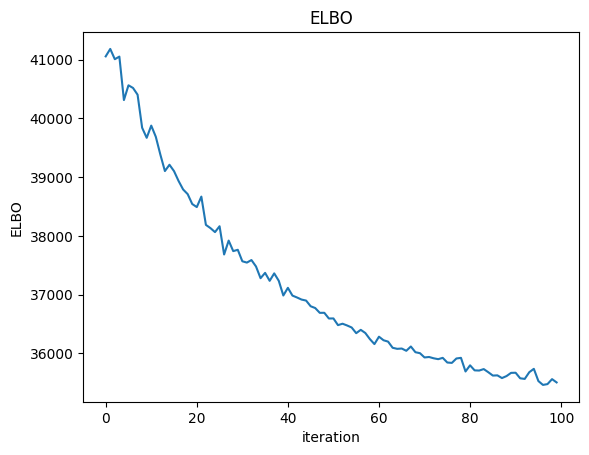

taking steps 101 to 200 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 35445.76:   0%|          | 0/100 [00:04<?, ?it/s]

Mean ELBO 35445.76:   1%|          | 1/100 [00:04<08:12,  4.97s/it]

Mean ELBO 35483.09:   1%|          | 1/100 [00:09<08:12,  4.97s/it]

...

Mean ELBO 34869.63:  98%|█████████▊| 98/100 [08:00<00:09,  4.73s/it]

Mean ELBO 34869.63:  99%|█████████▉| 99/100 [08:00<00:04,  4.75s/it]

Mean ELBO 34866.12:  99%|█████████▉| 99/100 [08:04<00:04,  4.75s/it]

Mean ELBO 34866.12: 100%|██████████| 100/100 [08:04<00:00,  4.76s/it]

Mean ELBO 34866.12: 100%|██████████| 100/100 [08:04<00:00,  4.85s/it]

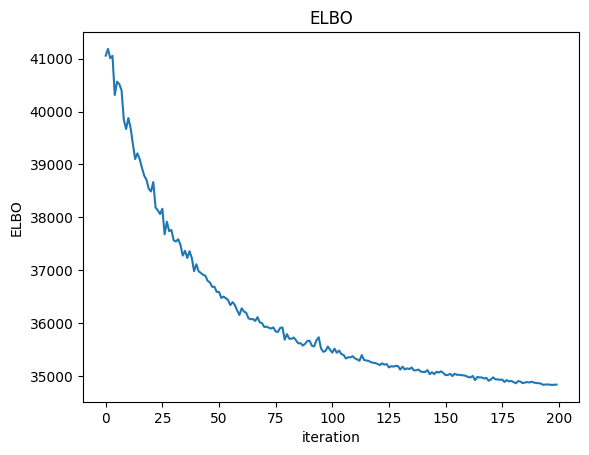

taking steps 201 to 300 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 34827.84:   0%|          | 0/100 [00:04<?, ?it/s]

Mean ELBO 34827.84:   1%|          | 1/100 [00:04<08:06,  4.92s/it]

Mean ELBO 34827.83:   1%|          | 1/100 [00:09<08:06,  4.92s/it]

...

Mean ELBO 34671.05:  98%|█████████▊| 98/100 [07:49<00:09,  4.75s/it]

Mean ELBO 34671.05:  99%|█████████▉| 99/100 [07:49<00:04,  4.81s/it]

Mean ELBO 34669.55:  99%|█████████▉| 99/100 [07:54<00:04,  4.81s/it]

Mean ELBO 34669.55: 100%|██████████| 100/100 [07:54<00:00,  4.78s/it]

Mean ELBO 34669.55: 100%|██████████| 100/100 [07:54<00:00,  4.74s/it]

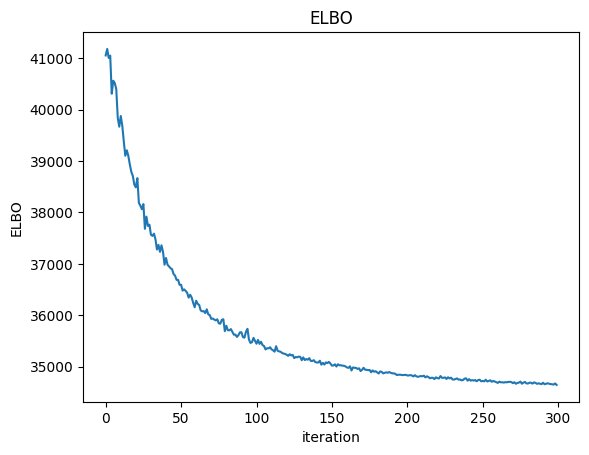

taking steps 301 to 400 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 34671.95:   0%|          | 0/100 [00:04<?, ?it/s]

Mean ELBO 34671.95:   1%|          | 1/100 [00:04<07:51,  4.76s/it]

Mean ELBO 34672.13:   1%|          | 1/100 [00:09<07:51,  4.76s/it]

...

Mean ELBO 34599.21:  98%|█████████▊| 98/100 [07:50<00:09,  4.78s/it]

Mean ELBO 34599.21:  99%|█████████▉| 99/100 [07:50<00:04,  4.78s/it]

Mean ELBO 34599.26:  99%|█████████▉| 99/100 [07:55<00:04,  4.78s/it]

Mean ELBO 34599.26: 100%|██████████| 100/100 [07:55<00:00,  4.77s/it]

Mean ELBO 34599.26: 100%|██████████| 100/100 [07:55<00:00,  4.75s/it]

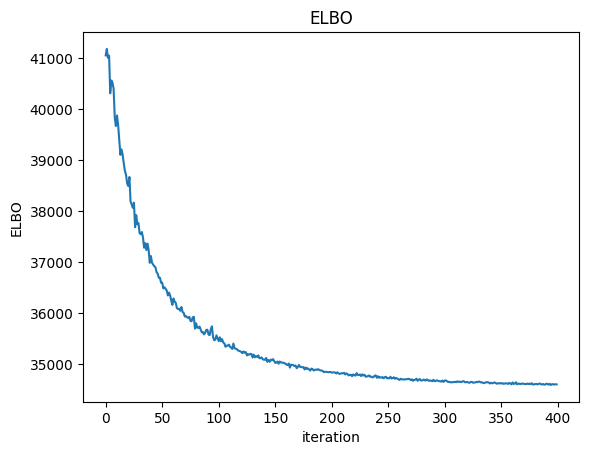

taking steps 401 to 500 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 34599.51:   0%|          | 0/100 [00:04<?, ?it/s]

Mean ELBO 34599.51:   1%|          | 1/100 [00:04<07:55,  4.81s/it]

Mean ELBO 34594.51:   1%|          | 1/100 [00:09<07:55,  4.81s/it]

...

Mean ELBO 34565.38:  98%|█████████▊| 98/100 [07:50<00:09,  4.76s/it]

Mean ELBO 34565.38:  99%|█████████▉| 99/100 [07:50<00:04,  4.76s/it]

Mean ELBO 34565.32:  99%|█████████▉| 99/100 [07:55<00:04,  4.76s/it]

Mean ELBO 34565.32: 100%|██████████| 100/100 [07:55<00:00,  4.75s/it]

Mean ELBO 34565.32: 100%|██████████| 100/100 [07:55<00:00,  4.75s/it]

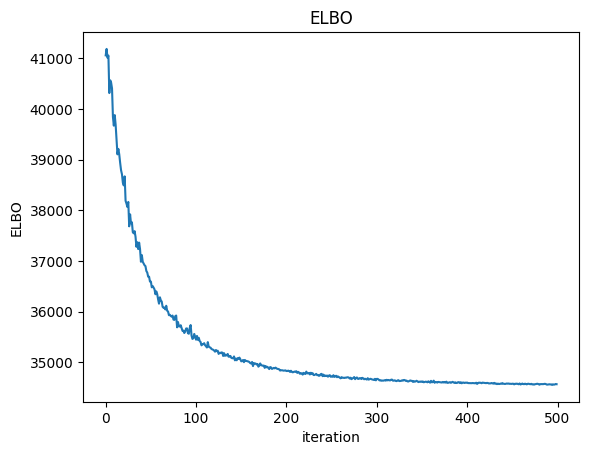

taking steps 501 to 600 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 34564.38:   0%|          | 0/100 [00:04<?, ?it/s]

Mean ELBO 34564.38:   1%|          | 1/100 [00:04<07:48,  4.73s/it]

Mean ELBO 34561.95:   1%|          | 1/100 [00:09<07:48,  4.73s/it]

...

Mean ELBO 34547.20:  98%|█████████▊| 98/100 [07:50<00:09,  4.74s/it]

Mean ELBO 34547.20:  99%|█████████▉| 99/100 [07:50<00:04,  4.74s/it]

Mean ELBO 34546.34:  99%|█████████▉| 99/100 [07:55<00:04,  4.74s/it]

Mean ELBO 34546.34: 100%|██████████| 100/100 [07:55<00:00,  4.73s/it]

Mean ELBO 34546.34: 100%|██████████| 100/100 [07:55<00:00,  4.75s/it]

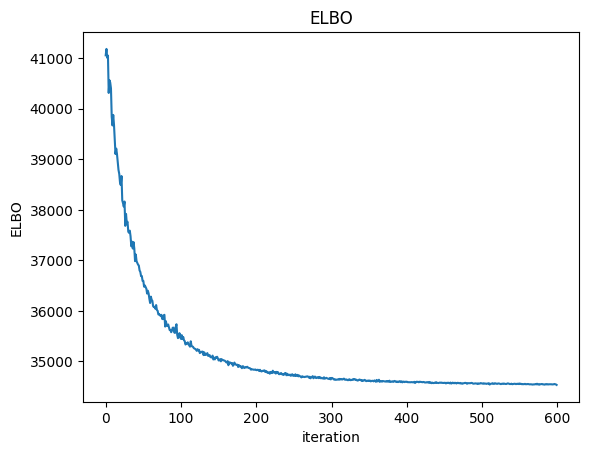

        discount  learning rate  dec temp    weight  subject
0       0.641901       0.496782  4.619712  0.742236        0
1       0.386898       0.123706  1.566785  0.492650        1
2       0.831875       0.226664  0.927875  0.481846        2
3       0.953325       0.713162  2.690428  0.353402        3
4       0.733991       0.900746  1.502917  0.173947        4
...          ...            ...       ...       ...      ...
102995  0.950497       0.113407  3.344684  0.289836      201
102996  0.872685       0.401319  1.244739  0.522273      202
102997  0.811691       0.780721  4.585929  0.622624      203
102998  0.739130       0.080466  2.949981  0.117592      204
102999  0.398266       0.099991  1.803453  0.683501      205

[103000 rows x 5 columns]


<Figure size 640x480 with 0 Axes>

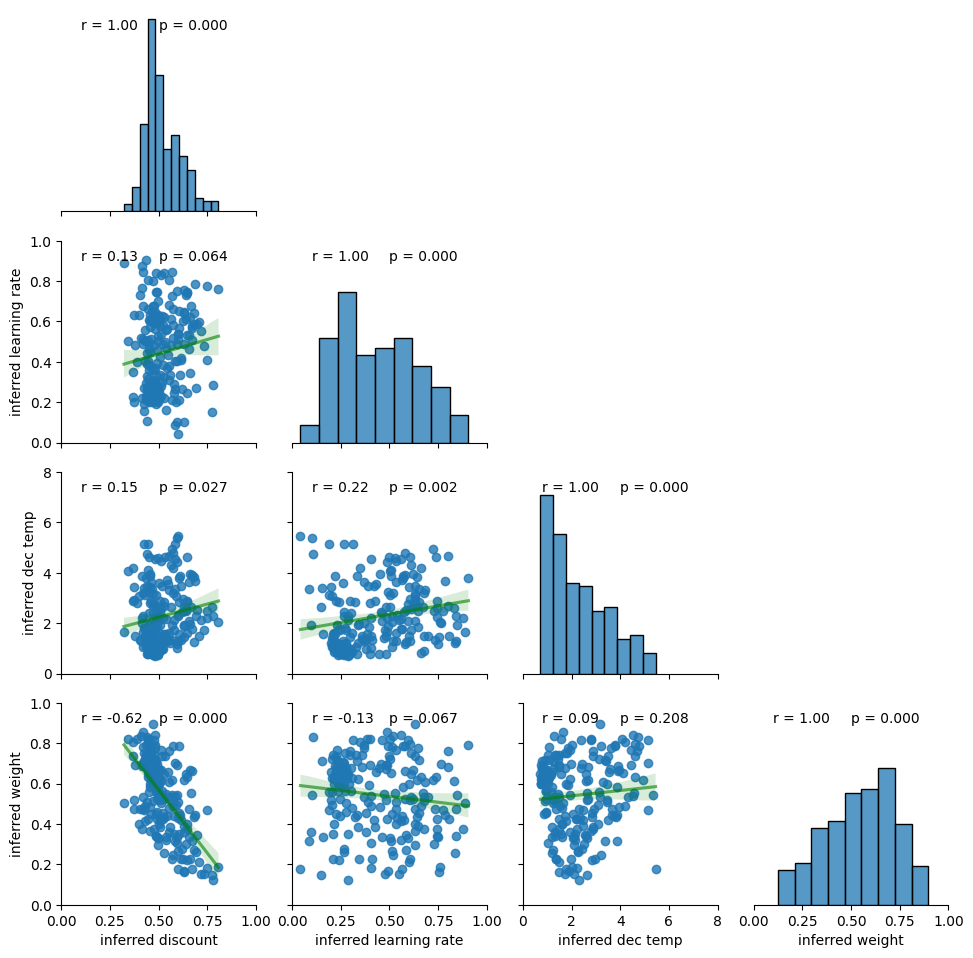

In [13]:
if run_inference:

    # remove old inference?
    remove_old = True

    # set up agent
    bayes_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, min_alpha, 
                                                base_dir, global_experiment_parameters, data["valid"], use_w=use_w, remove_old=remove_old)

    print('analyzing '+str(n_agents)+' data sets')

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    num_particles = 15


    print("this is inference using", type(inferrer))
    
    size_chunk = 100
    total_num_iter_so_far = 0

    for i in range(total_num_iter_so_far, num_steps, size_chunk):
        print('taking steps '+str(i+1)+' to '+str(i+size_chunk)+' out of total '+str(num_steps))

        fname_str = fname_base + str(total_num_iter_so_far+size_chunk)+'_'+str(n_agents)+'agents'

        iu.infer(inferrer, size_chunk, fname_str, num_particles, base_dir)
        total_num_iter_so_far += size_chunk

    inferrer.save_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.save_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 

    plt.figure()
    vars_of_interest = ["inferred "+name for name in param_names]
    f = sns.pairplot(data=mean_df, kind='reg', diag_kind="hist", corner=True,
                        plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                        grid_kws={"layout_pad": 1.5},
                        x_vars=vars_of_interest, y_vars=vars_of_interest)
    f.map(tu.annot_corrfunc)
    for p, p_range in enumerate(param_ranges):
        f.axes[n_pars-1,p].set_xlim(p_range)
        f.axes[p,0].set_ylim(p_range)
    plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
    plt.show()

    # # sample from posterior only at last time step and save results. Could be done at every step, if earlier posteriors are of interest, one can load the inferrer save and sample from that.
    # mean_df, sample_df, locs_df = tu.sample_posterior(inferrer, param_names, fname_str, base_dir) 

<b>Or:</b> Set up agent and inference. Load past inference, decide whether to resample posterior or used stored samples

In [14]:

if not run_inference:

    # set up agent
    mfmb_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, min_alpha, base_dir, global_experiment_parameters, data["valid"], remove_old=False)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(mfmb_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    plt.figure()
    plt.plot(inferrer.loss)
    plt.show()
    print("last ELBO:", inferrer.loss[-1])

    if resample:
        mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 


<Figure size 640x480 with 0 Axes>

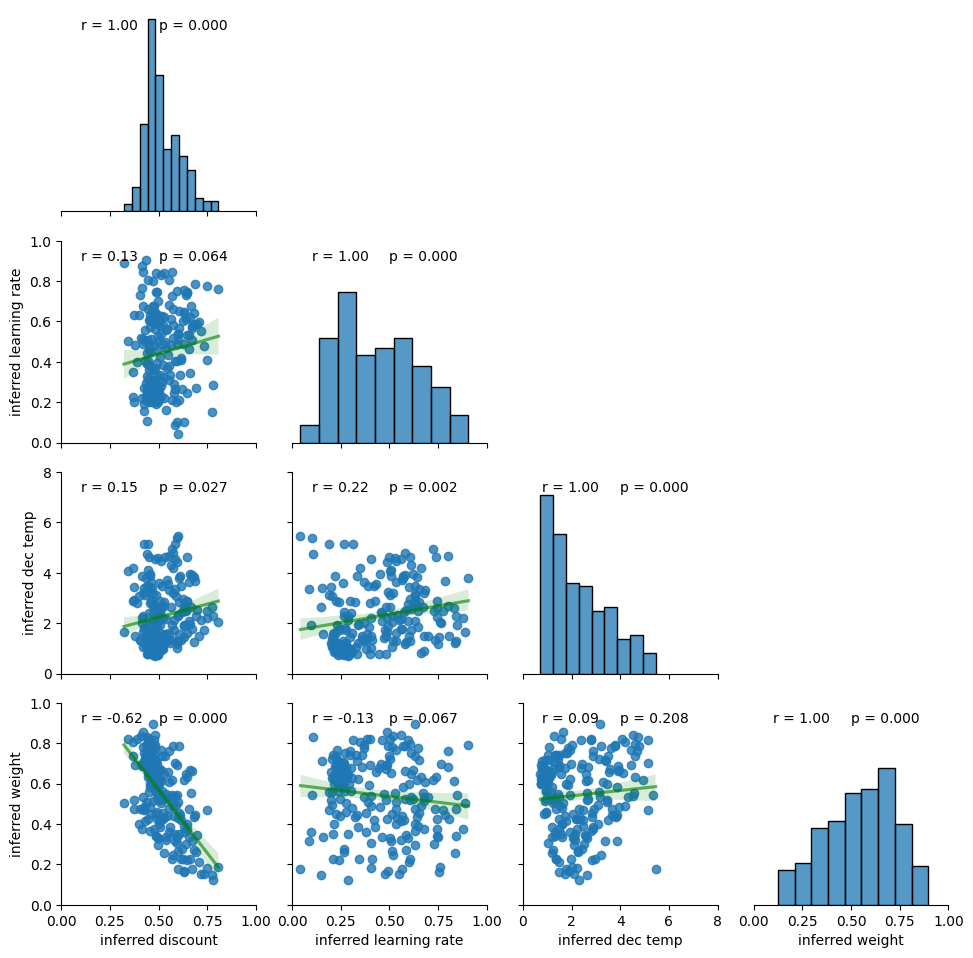

In [15]:

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    grid_kws={"layout_pad": 1.5},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

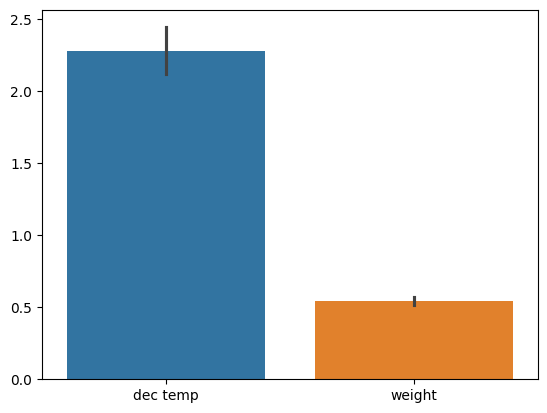

In [16]:
weight_df = pd.DataFrame({"dec temp": mean_df["inferred dec temp"], 
                            "weight": mean_df["inferred weight"]})

plt.figure()
sns.barplot(data=weight_df)
plt.show()

['inferred discount', 'inferred learning rate', 'inferred dec temp', 'inferred weight']


<Figure size 640x480 with 0 Axes>

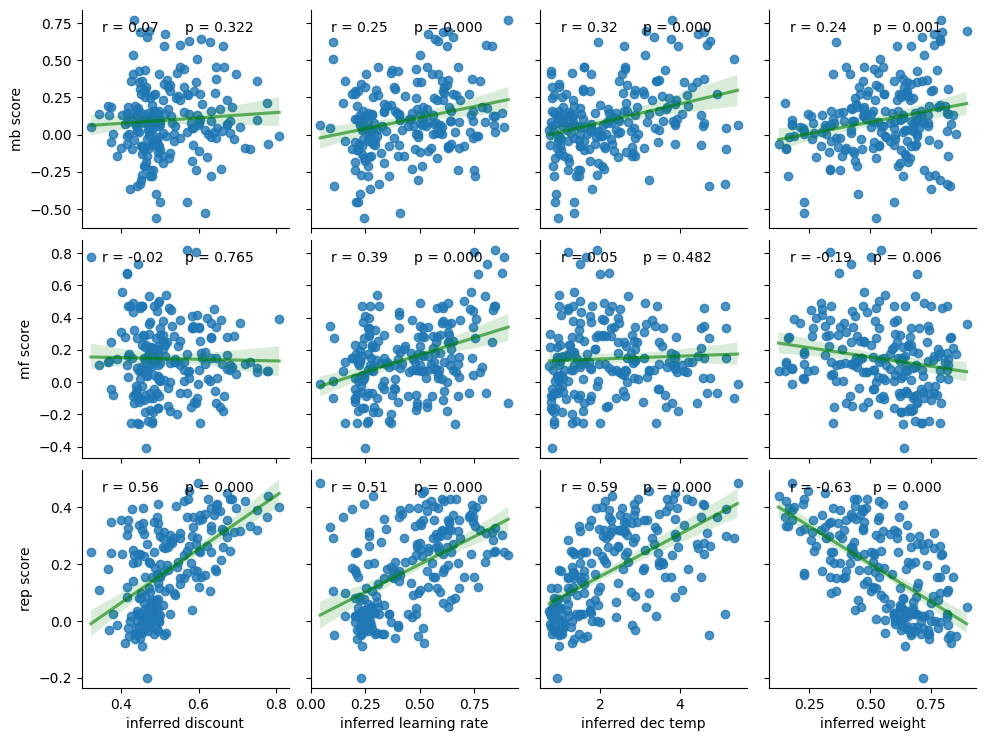

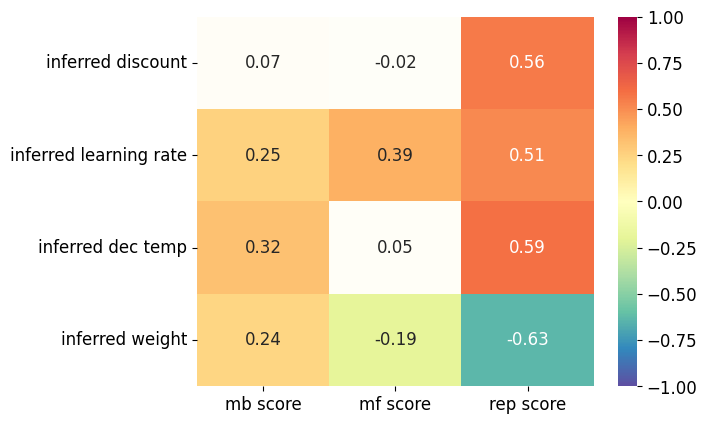

In [17]:
mean_scores_df = pd.concat([mean_df, scores_df], axis='columns')#, join="inner")

plt.figure()
x_vars_of_interest = ["inferred "+name for name in param_names]
print(x_vars_of_interest)
y_vars_of_interest = list(scores_df.keys())
f = sns.pairplot(data=mean_scores_df, kind='reg', #diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=x_vars_of_interest, y_vars=y_vars_of_interest)
f.map(tu.annot_corrfunc)
#for p, p_range in enumerate(param_plot_ranges):
#    f.axes[2,p].set_xlim(p_range)
#    f.axes[p,0].set_ylim(p_range)
#plt.title("BCC3 analysis 1 correlations with scores")
plt.show()

iu.plot_correlations(mean_scores_df, x_vars_of_interest, y_vars_of_interest)

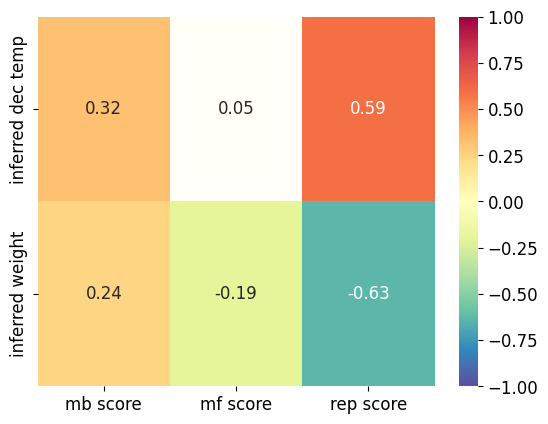

In [18]:
weight_names = ["inferred dec temp", "inferred weight"]

iu.plot_correlations(mean_scores_df, weight_names, y_vars_of_interest)